In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.append('..')

from src.config import DATA_RAW

D:\AI Eng\ML\_Projects\Employee Attrition Prediction & Workforce Analytics Platform\ml\data\raw\HR-Employee-Attrition.csv


In [2]:
df = pd.read_csv(DATA_RAW / 'HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## Checking Null and Duplicated Values

In [4]:
df.isna().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

# EDA

### Exploratory Data Analysis (EDA)

Let's start by visualizing the distribution of the target variable, 'Attrition', and then explore its relationships with other key features.

#### 1. Attrition Distribution

C:\Users\Admin\AppData\Local\Temp\ipykernel_19364\2104197782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='viridis')


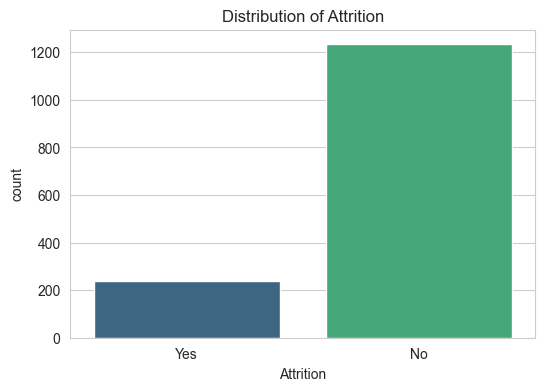

In [6]:
sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='viridis')
plt.title('Distribution of Attrition')
plt.show()

- The dataset shows an imbalance, with a significantly higher number of employees not attriting ('No') compared to those who do ('Yes'). This is a common characteristic in attrition datasets.

#### 2. Age Distribution by Attrition

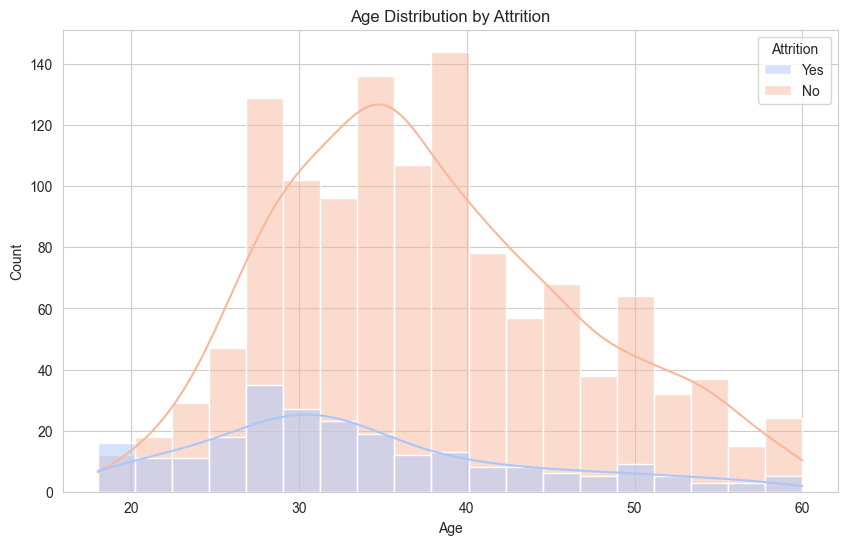

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, palette='coolwarm')
plt.title('Age Distribution by Attrition')
plt.show()

- Younger employees appear to have a higher propensity to attrite, as indicated by the 'Yes' attrition peak in the lower age ranges.

#### 3. Monthly Income Distribution by Attrition

C:\Users\Admin\AppData\Local\Temp\ipykernel_19364\232418483.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='plasma')


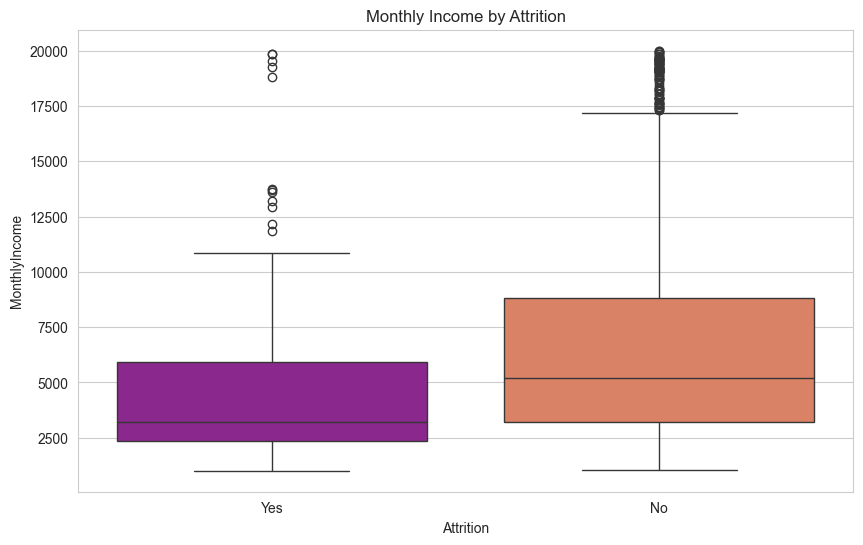

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='plasma')
plt.title('Monthly Income by Attrition')
plt.show()

- Employees with lower monthly incomes tend to have a higher attrition rate, indicated by the lower median income for 'Yes' attrition compared to 'No' attrition.

#### 4. Job Role Distribution by Attrition

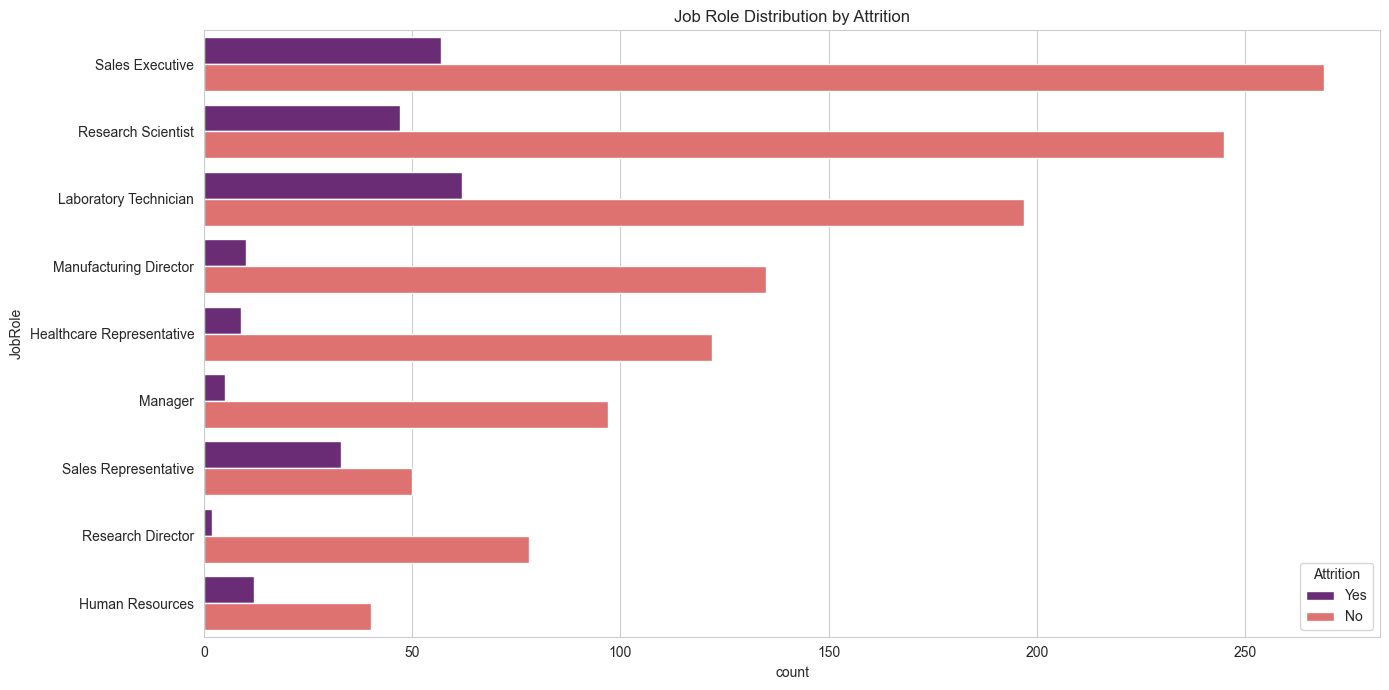

In [9]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, y='JobRole', hue='Attrition', palette='magma')
plt.title('Job Role Distribution by Attrition')
plt.tight_layout()
plt.show()

- Sales Representatives and Laboratory Technicians show higher attrition rates compared to other job roles, suggesting these roles might have specific challenges contributing to attrition.

#### 5. OverTime vs Attrition

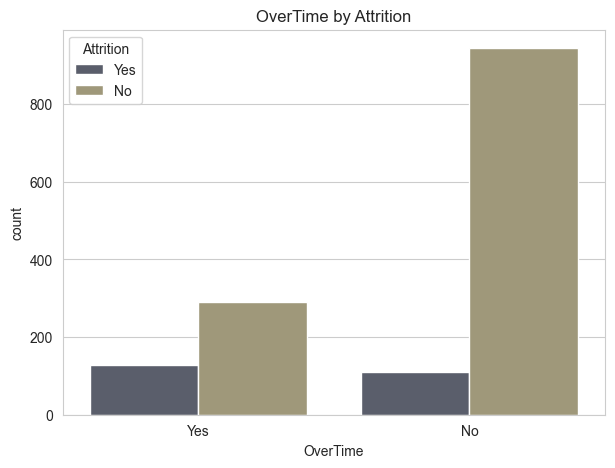

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='cividis')
plt.title('OverTime by Attrition')
plt.show()

- Employees working overtime have a noticeably higher attrition rate than those who do not, indicating that excessive work hours could be a significant factor.

#### 6. Marital Status vs Attrition

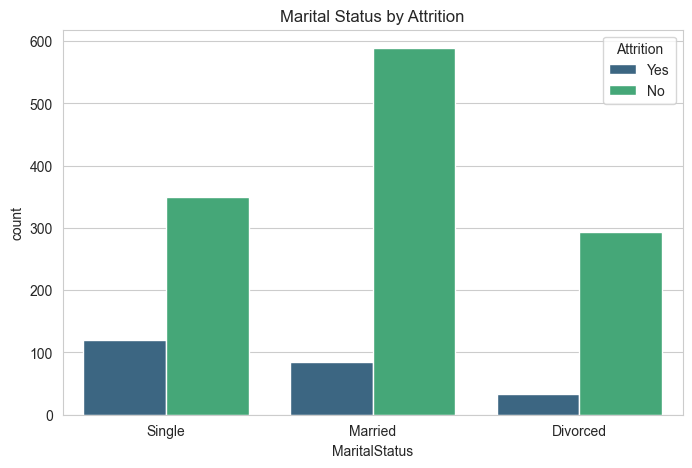

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='MaritalStatus', hue='Attrition', palette='viridis')
plt.title('Marital Status by Attrition')
plt.show()

- Single employees have a higher attrition rate compared to married or divorced counterparts.

#### 7. Correlation Matrix of Numerical Features

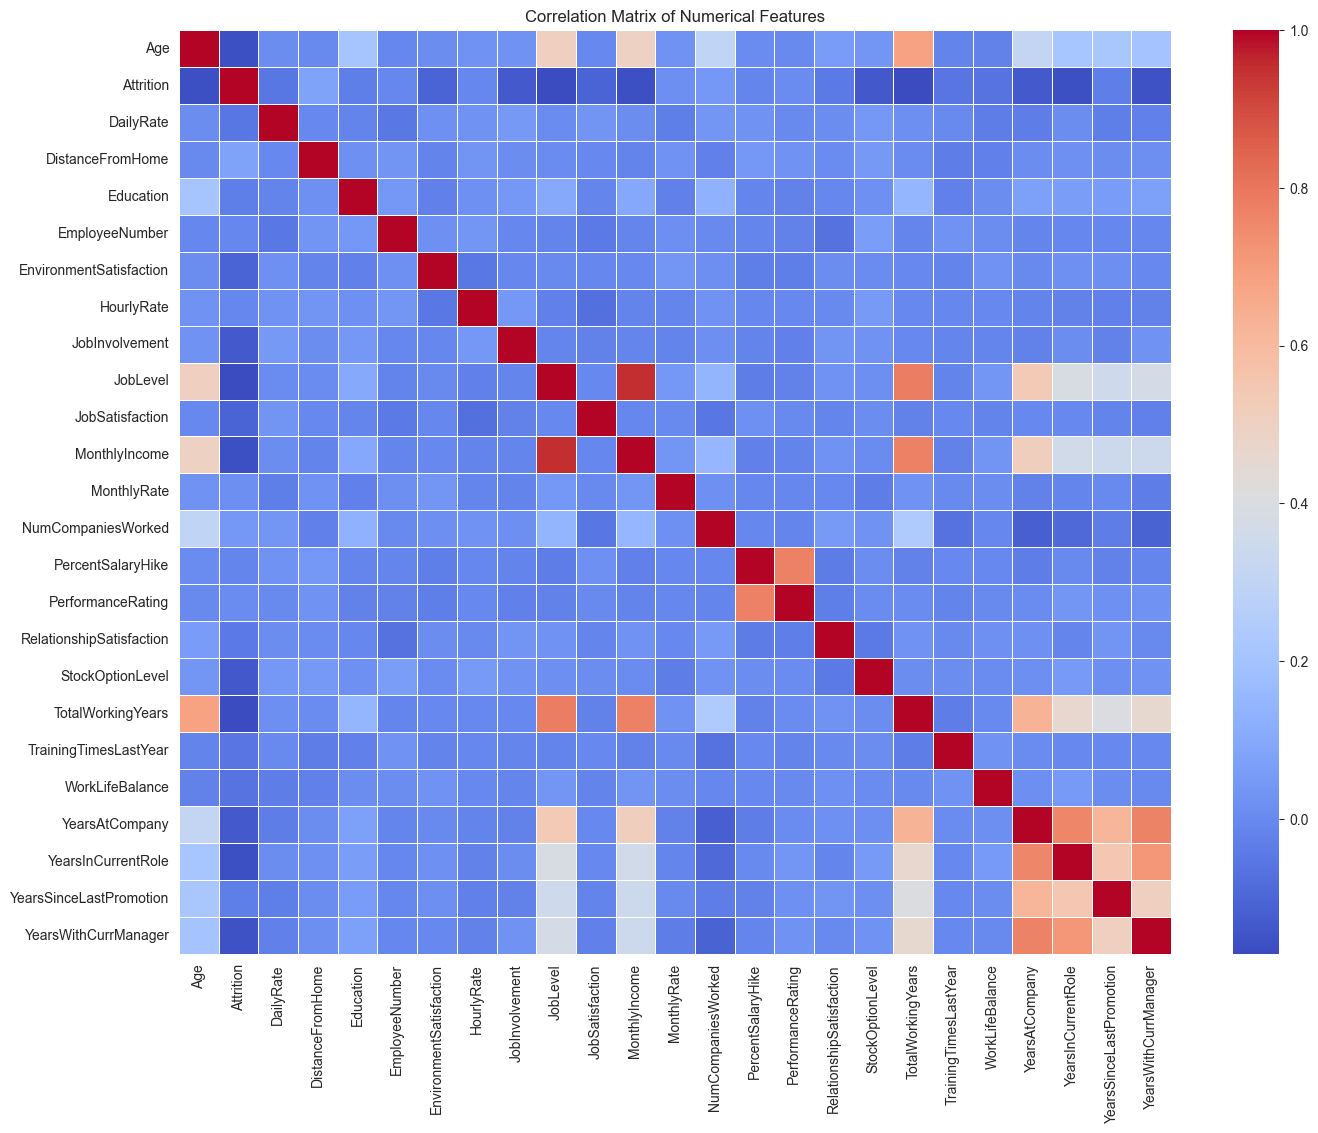

In [12]:
df_copy = df.copy()
df_copy['Attrition'] = df_copy['Attrition'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(16, 12))
numerical_df = df_copy.select_dtypes(include=np.number)
# Exclude 'EmployeeCount' and 'StandardHours' as they appear to be constant based on df.info()
numerical_df = numerical_df.drop(columns=['EmployeeCount', 'StandardHours'], errors='ignore')
sns.heatmap(numerical_df.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

- The correlation matrix provides insights into relationships between numerical features. Strong positive or negative correlations with 'Attrition' (if it were numerical) or among features themselves are visible and warrant further investigation. For example, 'TotalWorkingYears', 'YearsAtCompany', and 'MonthlyIncome' tend to be negatively correlated with attrition (higher values, lower attrition), while 'DistanceFromHome' and 'NumCompaniesWorked' might show positive correlations.

### Summary of EDA Findings:

1.  **Attrition Imbalance**: The dataset is imbalanced, with 'No' attrition being the majority class. This is a crucial point for subsequent model building, as it might require techniques like oversampling, undersampling, or using specific evaluation metrics.
2.  **Age**: Younger employees tend to attrite more frequently. This suggests that factors like initial career development, mentorship, or early job satisfaction could be critical retention drivers.
3.  **Monthly Income**: Employees with lower monthly incomes show a higher likelihood of attrition, indicating that compensation is a significant factor in employee retention.
4.  **Job Role**: Specific roles like Sales Representatives and Laboratory Technicians exhibit higher attrition rates. This might point to job-specific stressors, work-life balance issues, or perceived lack of career progression in these departments.
5.  **OverTime**: There is a strong correlation between working overtime and higher attrition rates, implying that excessive work hours negatively impact employee retention.
6.  **Marital Status**: Single employees have a higher attrition rate compared to married or divorced counterparts. This could be due to differing personal responsibilities or life stage priorities.
7.  **Key Numerical Feature Trends**: Features like 'TotalWorkingYears', 'YearsAtCompany', and 'MonthlyIncome' generally show an inverse relationship with attrition (higher values often correlate with lower attrition), while others such as 'DistanceFromHome' and 'NumCompaniesWorked' might show a direct relationship. Further detailed analysis of these correlations can reveal deeper insights.